# IGVF Perturb-seq Analysis

CRISPRi perturb-seq in HUES8 definitive endoderm (Huangfu lab).

**Data sources:**
- `inference_mudata.h5mu`: expression + guide matrices, cell metadata
- Calibrated result TSVs (`muddy_penguin_calibrated_*`): cis, trans, direct target results with empirical p-values
- GWAS catalog + OpenTargets for disease overlay

## 0. Setup and thresholds

In [1]:
import os
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

md.set_options(pull_on_update=False)
os.makedirs("cache", exist_ok=True)

# === THRESHOLDS ===
PVAL_ADJ_CUTOFF = 0.05
LOG2FC_CIS_MIN = 0.2
LOG2FC_TRANS_MIN = 1.0
N_TOP_REGULATORS = 20
GWAS_WINDOW = 50_000  # bp around features for GWAS overlap

# === PATHS ===
MUDATA_PATH = "./data/inference_mudata.h5mu"
CAL_PREFIX = "data/Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq_muddy_penguin_calibrated_"
GWAS_PATH = "data/gwas-catalog-download-associations-v1.0-full.tsv"
OT_ASSOC_PATH = "association_by_datasource_direct/"
OT_DISEASE_PATH = "disease/disease.parquet"

## 1. Load MuData (expression + guide matrices)

In [2]:
mdata = md.read_h5mu(MUDATA_PATH)
print(mdata)

gene_var = mdata.mod["gene"].var
guide_var = mdata.mod["guide"].var

# Ensembl ID -> gene symbol mapping
id_to_symbol = gene_var["symbol"].to_dict()
id_to_symbol.update(
    guide_var[["intended_target_name", "gene_name"]]
    .drop_duplicates()
    .set_index("intended_target_name")["gene_name"]
    .to_dict()
)

MuData object with n_obs × n_vars = 269491 × 23735
  obs:	'batch'
  uns:	'cis_per_element_results', 'cis_per_guide_results', 'trans_per_element_results', 'trans_per_guide_results'
  2 modalities
    gene:	269491 × 9584
      obs:	'batch', 'batch_number', 'n_counts', 'log1p_n_genes_by_counts', 'total_gene_umis', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'percent_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
      var:	'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_chr', 'gene_start', 'gene_end'
    guide:	269491 × 14151
      obs:	'batch', 'num_expressed_guides', 'total_guide_umis'
      var:	'guide_id', 'spacer', 'targeting', 'type', 'guide_chr', 'guide_start', 'guide_end', 'strand', 'pam', 'genomic_ele

## 2. Guide library overview

In [3]:
print(guide_var["type"].value_counts())
print(f"\nUnique intended targets: {guide_var['intended_target_name'].nunique()}")

assignments = mdata.mod["guide"].layers["guide_assignment"]
guides_per_cell = np.array(assignments.sum(axis=1)).flatten()
cells_assigned = (guides_per_cell > 0).sum()

print(f"\nCells with guide: {cells_assigned} / {assignments.shape[0]} ({cells_assigned/assignments.shape[0]:.1%})")
print(f"Guides/cell: median={np.median(guides_per_cell):.0f}, mean={np.mean(guides_per_cell):.2f}")

targeting = guide_var[guide_var["targeting"] == True]
gpt = targeting.groupby("intended_target_name", observed=True).size()
print(f"Guides/target: median={gpt.median():.0f}, mean={gpt.mean():.1f}")

print(f"\nBatches:\n{mdata.obs['batch'].value_counts()}")

type
targeting           12934
non-targeting         600
negative control      598
positive control       19
Name: count, dtype: int64

Unique intended targets: 2161

Cells with guide: 243972 / 269491 (90.5%)
Guides/cell: median=6, mean=6.97
Guides/target: median=6, mean=6.6

Batches:
batch
IGVFDS3434HGEI    44166
IGVFDS2129VHBD    43344
IGVFDS1437XFJK    33773
IGVFDS1403KZYV    31953
IGVFDS4079VXPX    31558
IGVFDS0788TUIL    30351
IGVFDS1313VGHL    27292
IGVFDS2520ZEYH    27054
Name: count, dtype: int64


## 3. Load calibrated inference results

These TSVs contain empirically calibrated p-values (already adjusted for multiple testing).
- **direct_target**: self-knockdown efficiency per element
- **cis**: effects on nearby genes
- **trans**: genome-wide distal effects

In [4]:
direct = pd.read_csv(CAL_PREFIX + "direct_target_results.tsv", sep="\t")
cis = pd.read_csv(CAL_PREFIX + "cis_results.tsv", sep="\t")
trans = pd.read_csv(CAL_PREFIX + "trans_results.tsv", sep="\t")

print(f"Direct targets: {direct.shape}")
print(f"Cis: {cis.shape}")
print(f"Trans: {trans.shape}")
print(f"\nColumns: {direct.columns.tolist()}")

Direct targets: (1098, 13)
Cis: (3977, 13)
Trans: (22844279, 13)

Columns: ['element_id', 'element_symbol', 'element_label', 'tested_gene_id', 'tested_gene_symbol', 'n_cells', 'log2fc', 'log2fc_se', 'is_cis', 'is_direct_target', 'posterior_pval', 'empirical_pval', 'empirical_pval_adj']


## 4. Direct target knockdown efficiency

In [5]:
direct_sig = direct[
    (direct["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (direct["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Significant direct targets: {len(direct_sig)} / {len(direct)}")
print(f"\nTop knockdowns:")
print(
    direct_sig.sort_values("empirical_pval_adj")
    .head(20)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Significant direct targets: 472 / 1098

Top knockdowns:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
        MALAT1             MALAT1 -2.802136        0.000000e+00      975
       NGFRAP1               BEX3 -2.548037        0.000000e+00     3216
          CNBP               CNBP -2.182033        0.000000e+00     1968
         HMGN3              HMGN3 -2.211705       1.337149e-211      462
        ZNF644             ZNF644 -2.546772       1.713011e-197      901
          CD81               CD81 -1.111068       1.895139e-161     4940
        ZNF532             ZNF532 -1.799527       1.820640e-147     1338
          ENO1               ENO1 -1.818485       7.940739e-126      304
        PHF21A             PHF21A -1.957458       1.381015e-119     1008
          TFRC               TFRC -2.741578       6.203075e-119     3584
       SMARCC1            SMARCC1 -1.226134       6.188193e-115     2012
         SOX17              SOX17 -2.309364       5.651694e-111     

## 5. Cis results: filtering and overview

In [6]:
cis_sig = cis[
    (cis["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (cis["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Cis significant: {len(cis_sig)} / {len(cis)}")
print(f"Unique elements: {cis_sig['element_symbol'].nunique()}")
print(f"Unique genes affected: {cis_sig['tested_gene_symbol'].nunique()}")

print("\nTop cis hits:")
print(
    cis_sig.sort_values("empirical_pval_adj")
    .head(15)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Cis significant: 518 / 3977
Unique elements: 487
Unique genes affected: 506

Top cis hits:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
          CNBP               CNBP -2.182033        0.000000e+00     1968
       NGFRAP1               BEX3 -2.548037        0.000000e+00     3216
        MALAT1             MALAT1 -2.802136        0.000000e+00      975
         HMGN3              HMGN3 -2.211705       1.337149e-211      462
        ZNF644             ZNF644 -2.546772       1.713011e-197      901
          CD81               CD81 -1.111068       1.895139e-161     4940
        ZNF532             ZNF532 -1.799527       1.820640e-147     1338
          ENO1               ENO1 -1.818485       7.940739e-126      304
        PHF21A             PHF21A -1.957458       1.381015e-119     1008
          TFRC               TFRC -2.741578       6.203075e-119     3584
       SMARCC1            SMARCC1 -1.226134       6.188193e-115     2012
         SOX17              SOX17

## 6. Trans results: filtering and caching

Trans table is ~22M rows. Filter once, cache to parquet.

In [7]:
TRANS_PARQUET = f"cache/trans_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_TRANS_MIN}.parquet"

if os.path.exists(TRANS_PARQUET):
    trans_sig = pd.read_parquet(TRANS_PARQUET)
    print(f"Loaded from cache: {len(trans_sig)} rows")
else:
    print("Filtering trans results...")
    trans_sig = trans[
        (trans["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
        & (trans["log2fc"].abs() > LOG2FC_TRANS_MIN)
        # & (trans["log2fc_se"] < trans["log2fc"].abs())  # effect > SE
    ].copy()
    trans_sig.to_parquet(TRANS_PARQUET, index=False)
    print(f"Filtered and saved: {len(trans_sig)} rows")

# Only keep targeting elements (exclude non-targeting controls)
targeting_elements = set(guide_var[guide_var["targeting"] == True]["intended_target_name"].unique())
targeting_symbols = set(id_to_symbol.get(e, e) for e in targeting_elements)
trans_sig = trans_sig[trans_sig["element_symbol"].isin(targeting_symbols)].copy()

print(f"\nTrans significant: {len(trans_sig)} ({trans_sig['element_symbol'].nunique()} elements, {trans_sig['tested_gene_symbol'].nunique()} genes)")
print(trans_sig.head())

Loaded from cache: 2304 rows

Trans significant: 2304 (192 elements, 1243 genes)
                                 element_id element_symbol element_label  \
0  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
1  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
2  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
3  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   
4  ENSG00000014164|chr8:143541215-143541439          ZC3H3     targeting   

    tested_gene_id tested_gene_symbol  n_cells    log2fc  log2fc_se  is_cis  \
0  ENSG00000162526              TSSK3      382  2.057008   0.294241   False   
1  ENSG00000215866          LINC01356      382  1.027955   0.088702   False   
2  ENSG00000288880    ENSG00000288880      382  2.583820   0.190982   False   
3  ENSG00000272562           H3-3A-DT      382  1.448928   0.282760   False   
4  ENSG00000168906              MAT2A      382  2.177373   0.185670

## 7. P-value and effect size distributions

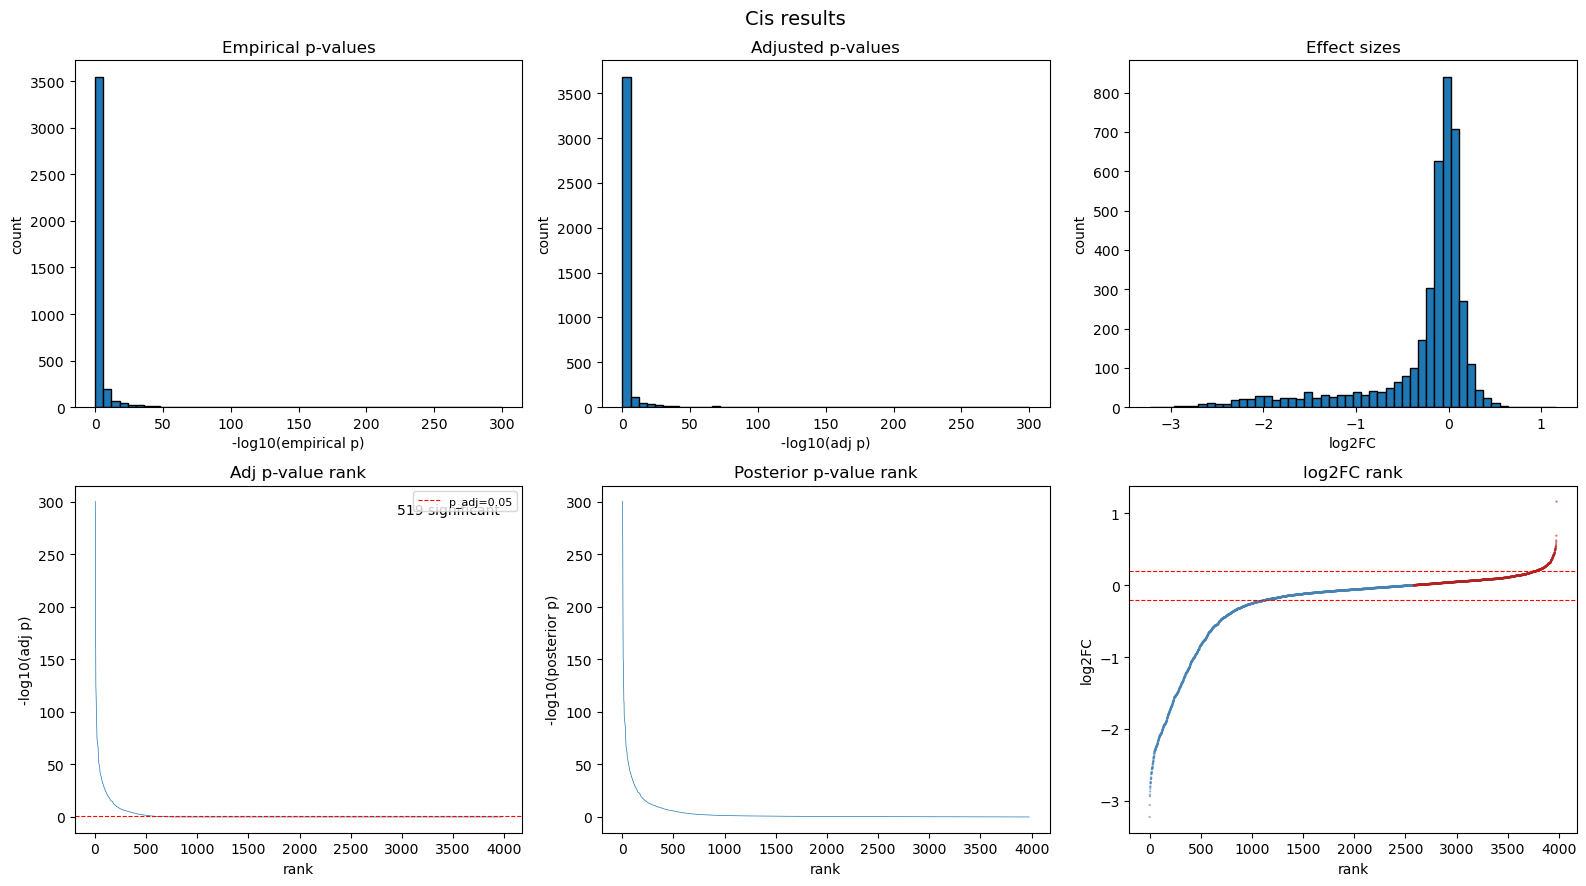

In [8]:
floor = 1e-300

# --- Cis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Cis results", fontsize=14)

cis_finite = cis[np.isfinite(cis["log2fc"])]

axes[0, 0].hist(-np.log10(cis["empirical_pval"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 0].set(xlabel="-log10(empirical p)", ylabel="count", title="Empirical p-values")

axes[0, 1].hist(-np.log10(cis["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 1].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[0, 2].hist(cis_finite["log2fc"], bins=50, edgecolor="black")
axes[0, 2].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

# Rank plots
padj_sorted = np.sort(cis["empirical_pval_adj"].values)
axes[1, 0].plot(np.arange(1, len(padj_sorted)+1), -np.log10(padj_sorted.clip(min=floor)), lw=0.5)
axes[1, 0].axhline(-np.log10(PVAL_ADJ_CUTOFF), color="r", ls="--", lw=0.8, label=f"p_adj={PVAL_ADJ_CUTOFF}")
axes[1, 0].text(0.95, 0.95, f"{(padj_sorted < PVAL_ADJ_CUTOFF).sum()} significant", transform=axes[1, 0].transAxes, ha="right", va="top")
axes[1, 0].set(xlabel="rank", ylabel="-log10(adj p)", title="Adj p-value rank")
axes[1, 0].legend(fontsize=8, loc="upper right")

post_sorted = np.sort(cis["posterior_pval"].values)
axes[1, 1].plot(np.arange(1, len(post_sorted)+1), -np.log10(post_sorted.clip(min=floor)), lw=0.5)
axes[1, 1].set(xlabel="rank", ylabel="-log10(posterior p)", title="Posterior p-value rank")

lfc_sorted = cis_finite["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[1, 2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.5, c=colors, alpha=0.5)
axes[1, 2].axhline(LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].axhline(-LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("cis_distributions.png", dpi=150)
plt.show()

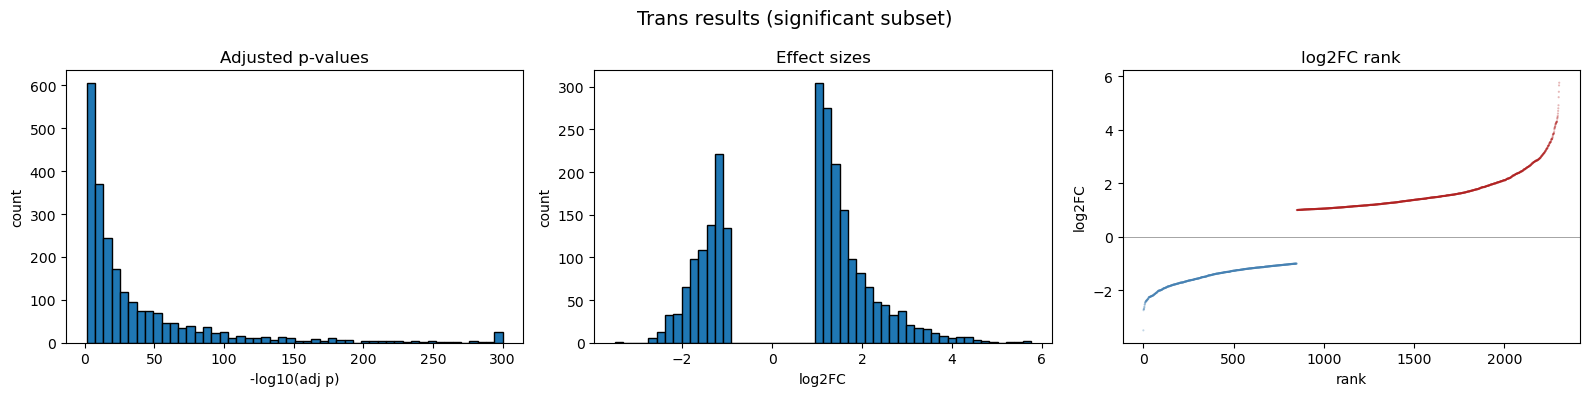

In [9]:
# --- Trans (on sig subset to avoid 22M point plots) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Trans results (significant subset)", fontsize=14)

axes[0].hist(-np.log10(trans_sig["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[1].hist(trans_sig["log2fc"], bins=50, edgecolor="black")
axes[1].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

lfc_sorted = trans_sig["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.3, c=colors, alpha=0.3)
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("trans_distributions.png", dpi=150)
plt.show()

## 8. Top trans regulators and their downstream targets

In [10]:
N_TOP_TARGETS = 5

top_trans = (
    trans_sig.groupby("element_symbol").size()
    .sort_values(ascending=False)
    .head(N_TOP_REGULATORS)
)

print("Top trans regulators:")
for symbol, count in top_trans.items():
    print(f"  {symbol}: {count} trans targets")

# Top up/down targets for leading regulators
for symbol in top_trans.index[:3]:
    subset = trans_sig[trans_sig["element_symbol"] == symbol]
    up = subset[subset["log2fc"] > 0].nlargest(N_TOP_TARGETS, "log2fc")
    down = subset[subset["log2fc"] < 0].nsmallest(N_TOP_TARGETS, "log2fc")

    print(f"\n--- {symbol}: {len(subset)} trans targets ---")
    print("  Upregulated:")
    for _, r in up.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")
    print("  Downregulated:")
    for _, r in down.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")

Top trans regulators:
  FOXH1: 705 trans targets
  SOX17: 615 trans targets
  SETDB1: 177 trans targets
  DBX1: 130 trans targets
  ZC3H3: 84 trans targets
  DNMT1: 49 trans targets
  RCOR2: 43 trans targets
  SNAI1: 33 trans targets
  HNF1B: 29 trans targets
  FOXA2: 26 trans targets
  POGK: 22 trans targets
  SMAD4: 16 trans targets
  ADNP2: 15 trans targets
  SMARCC1: 14 trans targets
  ZNF532: 12 trans targets
  ZNF90: 11 trans targets
  PCGF6: 10 trans targets
  ZNF644: 10 trans targets
  CHAMP1: 8 trans targets
  GATAD1: 8 trans targets

--- FOXH1: 705 trans targets ---
  Upregulated:
    LDB2: log2FC = 5.66
    FRMD4B: log2FC = 5.42
    FLT1: log2FC = 4.61
    COL5A2: log2FC = 4.52
    RYR2: log2FC = 4.45
  Downregulated:
    LINC02479: log2FC = -3.49
    ANKRD1: log2FC = -2.74
    ENSG00000253496: log2FC = -2.71
    GC: log2FC = -2.69
    CCL2: log2FC = -2.69

--- SOX17: 615 trans targets ---
  Upregulated:
    LRP1B: log2FC = 5.76
    NRXN1: log2FC = 4.92
    UNC13C: log2FC = 

## 9. Save filtered results

In [11]:
direct_sig.to_parquet(f"cache/direct_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
cis_sig.to_parquet(f"cache/cis_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
# trans_sig already saved in section 6

print(f"direct_sig: {len(direct_sig)} rows")
print(f"cis_sig: {len(cis_sig)} rows")
print(f"trans_sig: {len(trans_sig)} rows")

direct_sig: 472 rows
cis_sig: 518 rows
trans_sig: 2304 rows


In [12]:
trans_sig.head(2)

,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
0,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000162526,TSSK3,382,2.057008,0.294241,False,False,2.731303e-12,1.909303e-10,9.267096e-07
1,ENSG00000014164|chr8:143541215-143541439,ZC3H3,targeting,ENSG00000215866,LINC01356,382,1.027955,0.088702,False,False,4.693543e-31,4.712691e-26,6.408636e-22


In [13]:
trans_sig.describe()

,n_cells,log2fc,log2fc_se,posterior_pval,empirical_pval,empirical_pval_adj
count,2304.000000,2304.000000,2304.000000,2.304000e+03,2.304000e+03,2.304000e+03
mean,899.518229,0.531140,0.149563,1.034397e-07,7.917821e-07,1.467251e-03
std,328.759661,1.653377,0.067659,4.918326e-07,3.449435e-06,5.879555e-03
min,53.000000,-3.494927,0.026889,0.000000e+00,0.000000e+00,0.000000e+00
25%,814.000000,-1.193593,0.098318,6.670925e-63,1.644524e-52,5.105099e-48
50%,821.000000,1.130976,0.139516,5.041286e-26,7.160850e-22,8.030683e-18
75%,973.000000,1.589671,0.188527,2.224651e-13,2.364597e-11,1.263109e-07
max,2514.000000,5.759155,0.558772,5.139895e-06,3.280232e-05,4.954044e-02


In [14]:
trans_sig["element_symbol"].value_counts().head(20)

element_symbol
FOXH1      705
SOX17      615
SETDB1     177
DBX1       130
ZC3H3       84
DNMT1       49
RCOR2       43
SNAI1       33
HNF1B       29
FOXA2       26
POGK        22
SMAD4       16
ADNP2       15
SMARCC1     14
ZNF532      12
ZNF90       11
PCGF6       10
ZNF644      10
CHAMP1       8
GATAD1       8
Name: count, dtype: int64

In [15]:
# All perturbed TFs
all_tfs = guide_var[guide_var["targeting"] == True]["gene_name"].unique()
# Significant TFs (those with trans hits)
sig_tfs = trans_sig["element_symbol"].unique()
print(f"All perturbed TFs: {len(all_tfs)}")
print(f"TFs with sig trans hits: {len(sig_tfs)}")

All perturbed TFs: 2062
TFs with sig trans hits: 192


In [16]:
# All tested genes
all_genes = gene_var.index.tolist()  # Ensembl IDs
all_gene_symbols = gene_var["symbol"].unique()
# Significant target genes
sig_genes = trans_sig["tested_gene_symbol"].unique()
print(f"All tested genes: {len(all_genes)}")
print(f"Genes with sig trans hits: {len(sig_genes)}")

All tested genes: 9584
Genes with sig trans hits: 1243


---
## 10. Disease & GWAS (Working Group 3)

Goals:
1. Which TFs regulate disease/GWAS genes in this lineage
2. For TFs active in multiple lineages, is their activity convergent or divergent
3. Annotate GWAS variants near important TFs or upstream of their downstream targets

### 10a. GWAS catalog: positional overlap

In [17]:
gwas = pd.read_csv(GWAS_PATH, sep="\t", low_memory=False)
gwas = gwas[gwas["CHR_POS"].notna() & gwas["CHR_ID"].notna()].copy()
gwas["CHR_POS"] = pd.to_numeric(gwas["CHR_POS"], errors="coerce")
gwas = gwas[gwas["CHR_POS"].notna()].copy()
gwas["CHR_ID"] = gwas["CHR_ID"].astype(str)

print(f"GWAS catalog: {len(gwas)} associations, {gwas['DISEASE/TRAIT'].nunique()} traits")

GWAS catalog: 919591 associations, 41913 traits


In [18]:
# Step 1: precompute GWAS trait hits for every gene in the universe (run once)
GENE_GWAS_CACHE = f"cache/gene_gwas_all_{GWAS_WINDOW//1000}kb.parquet"

if os.path.exists(GENE_GWAS_CACHE):
    gene_gwas_all = pd.read_parquet(GENE_GWAS_CACHE)
    print(f"Loaded: {len(gene_gwas_all)} gene-trait pairs")
else:
    print("Precomputing GWAS overlap for all genes...")
    gene_coords_clean = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
    gene_coords_clean = gene_coords_clean[gene_coords_clean["gene_chr"].notna()]
    gene_coords_clean["chr_clean"] = gene_coords_clean["gene_chr"].str.replace("chr", "")

    records = []
    for i, (ens_id, gc) in enumerate(gene_coords_clean.iterrows()):
        if i % 1000 == 0:
            print(f"  {i}/{len(gene_coords_clean)}")
        nearby = gwas[
            (gwas["CHR_ID"] == gc["chr_clean"])
            & (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW)
            & (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
        ]
        for trait in nearby["DISEASE/TRAIT"].values:
            records.append({"gene_id": ens_id, "symbol": gc["symbol"], "trait": trait})

    gene_gwas_all = pd.DataFrame(records)
    gene_gwas_all.to_parquet(GENE_GWAS_CACHE, index=False)
    print(f"Saved: {len(gene_gwas_all)} gene-trait pairs")

print(f"Genes with any GWAS overlap: {gene_gwas_all['gene_id'].nunique()}")
print(f"Traits covered: {gene_gwas_all['trait'].nunique()}")

Loaded: 965472 gene-trait pairs
Genes with any GWAS overlap: 9500
Traits covered: 33242


In [19]:
# Parse element coordinates from element_id column
def parse_element_coords(df):
    parts = df["element_id"].str.extract(r"(.+)\|chr(\w+):(\d+)-(\d+)")
    df = df.copy()
    df["el_chr"] = parts[1].values
    df["el_start"] = parts[2].astype(float).values
    df["el_end"] = parts[3].astype(float).values
    return df

# Top 20 "most-perturbing" TFs
# Filter using isin()
top_trans_TFs = trans_sig["element_symbol"].value_counts().head(20).index
trans_sig_top_TFs = trans_sig[trans_sig["element_symbol"].isin(top_trans_TFs)]
print(f"Filtered: {len(trans_sig_top_TFs):,} rows")

# Top TFs only
trans_sig_coords = parse_element_coords(trans_sig_top_TFs)

# # All TFs
# trans_sig_coords = parse_element_coords(trans_sig)

# Unique element coordinates
element_coords = (
    trans_sig_coords[["element_symbol", "el_chr", "el_start", "el_end"]]
    .drop_duplicates("element_symbol")
)

# Gene coordinates from gene_var
gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")

# --- GWAS SNPs near perturbed TF elements ---
tf_gwas_hits = []
for _, el in element_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["el_chr"])
        & (gwas["CHR_POS"] >= el["el_start"] - GWAS_WINDOW)
        & (gwas["CHR_POS"] <= el["el_end"] + GWAS_WINDOW)
    ]
    for _, snp in nearby.iterrows():
        tf_gwas_hits.append({
            "tf_symbol": el["element_symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

tf_gwas = pd.DataFrame(tf_gwas_hits)
print(f"=== GWAS SNPs within {GWAS_WINDOW//1000}kb of TF elements ===")
print(f"Hits: {len(tf_gwas)}, TFs: {tf_gwas['tf_symbol'].nunique()}, Traits: {tf_gwas['trait'].nunique()}")

# --- GWAS SNPs near downstream target genes ---
target_genes = set(trans_sig["tested_gene_id"].unique())
target_coords = gene_coords[gene_coords.index.isin(target_genes)]

gene_gwas_hits = []
for ens_id, gc in target_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == gc["chr_clean"])
        & (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW)
        & (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
    ]
    for _, snp in nearby.iterrows():
        gene_gwas_hits.append({
            "gene_ensembl": ens_id,
            "gene_symbol": gc["symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

gene_gwas = pd.DataFrame(gene_gwas_hits)
print(f"\n=== GWAS SNPs within {GWAS_WINDOW//1000}kb of trans target genes ===")
print(f"Hits: {len(gene_gwas)}, Genes: {gene_gwas['gene_symbol'].nunique()}, Traits: {gene_gwas['trait'].nunique()}")

Filtered: 2,017 rows


=== GWAS SNPs within 50kb of TF elements ===
Hits: 1338, TFs: 20, Traits: 596

=== GWAS SNPs within 50kb of trans target genes ===
Hits: 144295, Genes: 1230, Traits: 16308


In [20]:
gene_gwas[["pvalue"]].describe()

,pvalue
count,1.442950e+05
mean,5.442587e-07
std,1.731370e-06
min,0.000000e+00
25%,5.000000e-20
50%,5.000000e-12
75%,1.000000e-08
max,1.000000e-05


### 10b. GWAS trait enrichment (Fisher exact test)

In [21]:
trait_counts = gwas["DISEASE/TRAIT"].value_counts()
total_snps = len(gwas)

def trait_enrichment(gwas_hits_df, label, min_hits=5):
    hit_traits = gwas_hits_df["trait"].value_counts()
    hit_traits = hit_traits[hit_traits >= min_hits]
    n_hits = len(gwas_hits_df)

    results = []
    for trait, observed in hit_traits.items():
        catalog_n = trait_counts.get(trait, 1)
        expected = catalog_n * (n_hits / total_snps)
        a = observed
        b = max(catalog_n - observed, 0)
        c = max(n_hits - observed, 0)
        d = max(total_snps - catalog_n - c, 0)
        odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        results.append({
            "trait": trait, "observed": observed, "catalog_total": catalog_n,
            "expected": round(expected, 2), "enrichment": round(observed / max(expected, 0.01), 2),
            "odds_ratio": round(odds_ratio, 2), "pvalue": pval,
        })

    edf = pd.DataFrame(results)
    edf["fdr"] = multipletests(edf["pvalue"], method="fdr_bh")[1]
    edf = edf.sort_values("fdr")
    print(f"\n=== {label}: trait enrichment (>={min_hits} hits) ===")
    print(edf.head(20).to_string(index=False))
    return edf

tf_enrichment = trait_enrichment(tf_gwas, "Near TF elements")
gene_enrichment = trait_enrichment(gene_gwas, "Near target genes")


=== Near TF elements: trait enrichment (>=5 hits) ===
                                                       trait  observed  catalog_total  expected  enrichment  odds_ratio       pvalue          fdr
                                             Prostate cancer        63           3071      4.47       14.10       15.03 9.000194e-50 4.680101e-48
                             Alanine aminotransferase levels        52           1767      2.57       20.23       21.61 4.273036e-49 1.110989e-47
                                        ICAM5 protein levels         8             77      0.11       71.41       80.04 3.787545e-13 6.565078e-12
                                Prostate cancer (late onset)        11            284      0.41       26.62       27.87 8.260910e-13 1.073918e-11
Aspartate aminotransferase to alanine aminotransferase ratio        10            217      0.32       31.67       33.40 1.619740e-12 1.684529e-11
                                             Type 2 diabetes        3

### 10c. OpenTargets: gene-disease associations

In [16]:
ot = pd.read_parquet(OT_ASSOC_PATH)
diseases = pd.read_parquet(OT_DISEASE_PATH)

disease_id_to_name = diseases.set_index("id")["name"].to_dict()

print(f"OpenTargets associations: {len(ot)}")
print(f"Datasources: {ot['aggregationValue'].unique()}")
print(f"Diseases: {len(diseases)}")

# Therapeutic areas
all_areas = diseases["therapeuticAreas"].dropna().explode().unique()
print(f"\nTherapeutic areas:")
for aid in sorted(all_areas):
    print(f"  {disease_id_to_name.get(aid, aid)}")

OpenTargets associations: 4732211
Datasources: ['europepmc' 'cancer_gene_census' 'gwas_credible_sets'
 'clinical_precedence' 'impc' 'expression_atlas' 'intogen' 'crispr'
 'cancer_biomarkers' 'eva_somatic' 'eva' 'genomics_england'
 'uniprot_literature' 'gene_burden' 'uniprot_variants' 'gene2phenotype'
 'clingen' 'reactome' 'crispr_screen' 'orphanet']
Diseases: 47030

Therapeutic areas:
  cardiovascular disease
  immune system disease
  nervous system disease
  phenotype
  endocrine system disease
  measurement
  medical procedure
  infectious disease
  hematologic disease
  animal disease
  urinary system disease
  gastrointestinal disease
  integumentary system disease
  biological_process
  psychiatric disorder
  disorder of ear
  disorder of visual system
  cancer or benign tumor
  musculoskeletal or connective tissue disease
  injury, poisoning or other complication
  respiratory or thoracic disease
  pregnancy or perinatal disease
  reproductive system or breast disease
  genetic, 

In [17]:
# Filter to GWAS evidence
ot_gwas = ot[ot["aggregationValue"] == "gwas_credible_sets"].copy()
ot_gwas["disease_name"] = ot_gwas["diseaseId"].map(disease_id_to_name)

# Extract Ensembl IDs for trans target genes and TF elements
# Parse ensembl IDs from element_id
trans_sig_ens = trans_sig["element_id"].str.extract(r"(ENSG\d+)")[0].unique()
trans_target_ens = trans_sig["tested_gene_id"].unique()

ot_gwas_genes = set(ot_gwas["targetId"].unique())

print(f"GWAS credible set associations: {len(ot_gwas)}")
print(f"Trans target genes with OT GWAS evidence: {len(set(trans_target_ens) & ot_gwas_genes)} / {len(trans_target_ens)}")
print(f"Perturbed TF elements with OT GWAS evidence: {len(set(trans_sig_ens) & ot_gwas_genes)} / {len(trans_sig_ens)}")

GWAS credible set associations: 949600
Trans target genes with OT GWAS evidence: 1002 / 1243
Perturbed TF elements with OT GWAS evidence: 185 / 190
